In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Encuentra los datos desde src, PRE_07_deployment o la raíz del repositorio.
carpeta_actual = Path.cwd().resolve()
rutas = [carpeta_actual] + list(carpeta_actual.parents)
ruta_datos = next(
    (base / carpeta / "data" / "house_data.csv"
     for base in rutas
     for carpeta in ("", "PRE_07_deployment")
     if (base / carpeta / "data" / "house_data.csv").is_file()),
    None,
)
if ruta_datos is None:
    raise FileNotFoundError("No se encontró data/house_data.csv desde la carpeta actual.")

dataset = pd.read_csv(ruta_datos)
dataset.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
# Tamaño del dataset
dataset.shape

(21613, 21)

In [4]:
# Tipos de datos y cantidad de valores disponibles.
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [5]:
# Búsqueda de valores nulos.
dataset.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [6]:
# Filas duplicadas e identificadores repetidos.
pd.Series({
    "Filas duplicadas": dataset.duplicated().sum(),
    "Identificadores repetidos": dataset["id"].duplicated().sum(),
})

Filas duplicadas               0
Identificadores repetidos    177
dtype: int64

In [7]:
# Variables utilizadas en el modelo y variable objetivo.
features = [
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot",
    "floors", "waterfront", "condition",
]
variables = ["price"] + features

# Estadísticas generales
estadisticas = dataset[variables].describe().transpose()
estadisticas.round(2)

,count,mean,std,min,25%,50%,75%,max
price,21613.0,540088.14,367127.20,75000.0,321950.00,450000.00,645000.0,7700000.0
bedrooms,21613.0,3.37,0.93,0.0,3.00,3.00,4.0,33.0
bathrooms,21613.0,2.11,0.77,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,2079.90,918.44,290.0,1427.00,1910.00,2550.0,13540.0
sqft_lot,21613.0,15106.97,41420.51,520.0,5040.00,7618.00,10688.0,1651359.0
floors,21613.0,1.49,0.54,1.0,1.00,1.50,2.0,3.5
waterfront,21613.0,0.01,0.09,0.0,0.00,0.00,0.0,1.0
condition,21613.0,3.41,0.65,1.0,3.00,3.00,4.0,5.0


In [8]:
# Frecuencias de las variables discretas.
for columna in ["bedrooms", "floors", "waterfront", "condition"]:
    print(f"\nFrecuencias de {columna}")
    print(dataset[columna].value_counts().sort_index())


Frecuencias de bedrooms
bedrooms
0       13
1      199
2     2760
3     9824
4     6882
5     1601
6      272
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

Frecuencias de floors
floors
1.0    10680
1.5     1910
2.0     8241
2.5      161
3.0      613
3.5        8
Name: count, dtype: int64

Frecuencias de waterfront
waterfront
0    21450
1      163
Name: count, dtype: int64

Frecuencias de condition
condition
1       30
2      172
3    14031
4     5679
5     1701
Name: count, dtype: int64


In [9]:
# Distribución de los precios.
plt.figure(figsize=(10, 6))
plt.hist(dataset["price"], bins=40, color="tab:blue", edgecolor="white")
plt.title("Distribución del precio de las viviendas")
plt.xlabel("Precio")
plt.ylabel("Número de viviendas")
plt.ticklabel_format(style="plain", axis="x")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 1 Axes>

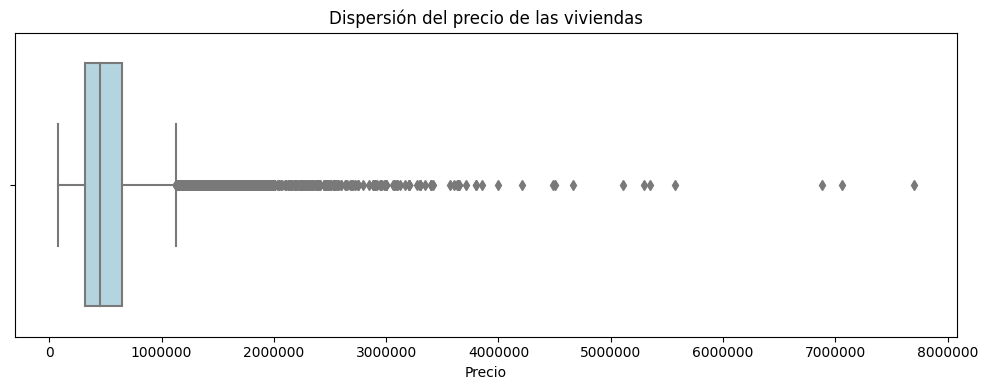

In [10]:
# Diagrama de caja para observar dispersión y posibles valores atípicos.
plt.figure(figsize=(10, 4))
sns.boxplot(x=dataset["price"], color="lightblue")
plt.title("Dispersión del precio de las viviendas")
plt.xlabel("Precio")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

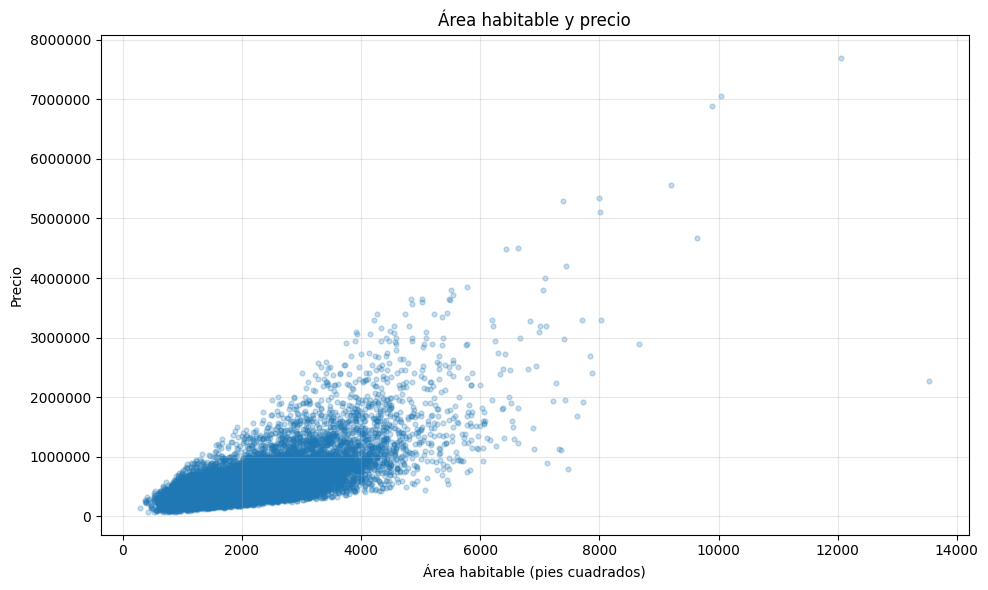

In [11]:
# Relación entre Área habitable y precio.
plt.figure(figsize=(10, 6))
plt.scatter(dataset["sqft_living"], dataset["price"], alpha=0.25, s=12)
plt.title("Área habitable y precio")
plt.xlabel("Área habitable (pies cuadrados)")
plt.ylabel("Precio")
plt.ticklabel_format(style="plain", axis="y")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Resumen de precios según el número de habitaciones.
precios_por_habitaciones = dataset.groupby("bedrooms")["price"].agg(
    ["count", "mean", "median"]
)
precios_por_habitaciones.round(2)

,count,mean,median
bedrooms,,,
0,13,409503.85,288000.0
1,199,317642.88,299000.0
2,2760,401372.68,374000.0
3,9824,466232.08,413000.0
4,6882,635419.50,549997.5
5,1601,786599.83,620000.0
6,272,825520.64,650000.0
7,38,951184.66,728580.0
8,13,1105076.92,700000.0


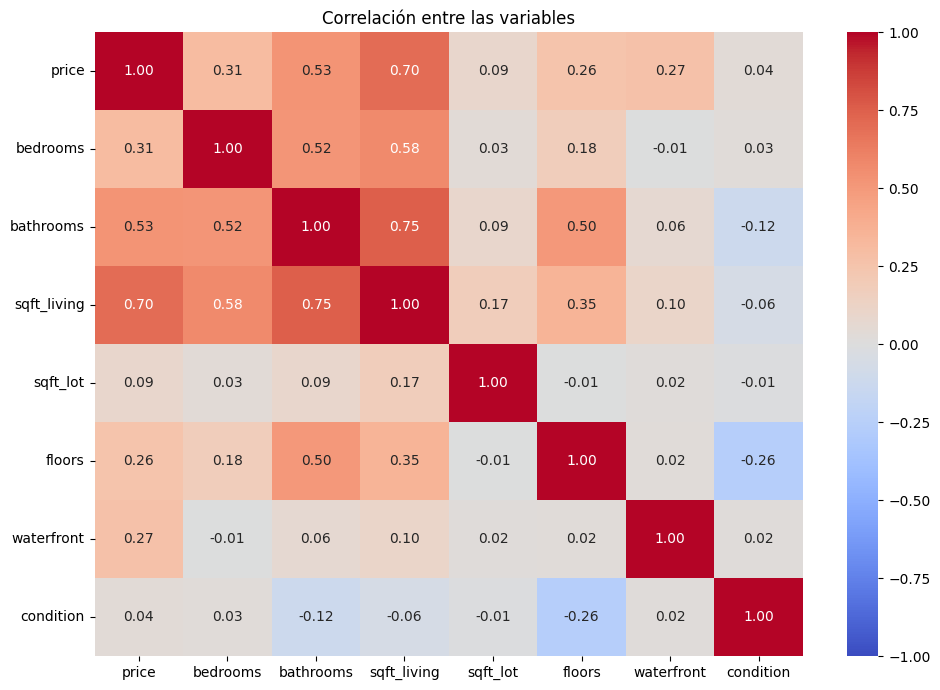

In [13]:
# Correlación lineal entre las variables del modelo y el precio.
correlaciones = dataset[variables].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0)
plt.title("Correlación entre las variables")
plt.tight_layout()
plt.show()

In [14]:
# Resumen
relacion_precio = correlaciones.loc[features, "price"].dropna()
variable_mayor_relacion = relacion_precio.abs().idxmax()
print(f"El dataset contiene {dataset.shape[0]:,} registros y {dataset.shape[1]} columnas.")
print(f"Se encontraron {dataset.isna().sum().sum()} valores nulos y "
      f"{dataset.duplicated().sum()} filas duplicadas.")
print(f"Precio promedio: {estadisticas.loc['price', 'mean']:,.2f}")
print(f"Mediana del precio: {estadisticas.loc['price', '50%']:,.2f}")
print(f"La variable del modelo con mayor correlación absoluta con el precio es "
      f"{variable_mayor_relacion} ({relacion_precio[variable_mayor_relacion]:.2f}).")

El dataset contiene 21,613 registros y 21 columnas.
Se encontraron 0 valores nulos y 0 filas duplicadas.
Precio promedio: 540,088.14
Mediana del precio: 450,000.00
La variable del modelo con mayor correlación absoluta con el precio es sqft_living (0.70).
